In [1]:
import os
import pickle

import matplotlib.pyplot as plt
import mplhep as hep
import nsbi_common_utils
import numpy as np
import pandas as pd
from nsbi_common_utils.training.utils import load_trained_model

/pbs/home/r/rchakkap/.local/lib/python3.11/site-packages/nsbi_common_utils/plotting.py:10: FutureWarning: ``set_style`` is deprecated: Naming convention is changing to match mpl. Use ``mplhep.style.use()``.
  hep.set_style("ATLAS")


In [2]:
BASE_PATH = "./data_nsbi_tutorial/"

In [3]:
nodes = [0, 5, 10]

signals = {
    f"signal_{n:g}": pd.read_parquet(f"{BASE_PATH}/signal_{n:g}.parquet") for n in nodes
}
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

In [4]:
TOTAL_YIELD = {}
TOTAL_YIELD["signal"] = signals["signal_10"].weight.sum()
TOTAL_YIELD["background"] = background.weight.sum()

In [5]:
asimov_dataset = (
    pd.concat([background, signals["signal_10"]], ignore_index=True)
    .astype("float32")
    .copy()
)
weights_asimov = np.array(asimov_dataset.weight)
PATH_TO_WEIGHTS = "saved_weights/asimov_weight_array.npy"
os.makedirs(os.path.dirname(PATH_TO_WEIGHTS), exist_ok=True)
np.save(PATH_TO_WEIGHTS, weights_asimov)
DATA = np.sum(weights_asimov)

In [6]:
training_features = ["x1", "x2", "x3", "x4", "x5"]

In [7]:
PATH_TO_RATIOS = {}
PATH_TO_RATIOS["signal"] = "saved_ratios_asimov/ratio_sig10vsRef.npy"
PATH_TO_RATIOS["background"] = "saved_ratios_asimov/ratio_BkgvsRef.npy"

In [8]:
for path in PATH_TO_RATIOS.values():
    os.makedirs(os.path.dirname(path), exist_ok=True)

In [9]:
path_to_saved_scaler = f"models_sig10vsRef/model_scaler0.bin"
path_to_saved_model = f"models_sig10vsRef/model0.onnx"
path_to_calibrated_object = f"models_sig10vsRef/model_calibrated_hist0.obj"

scaler, model = load_trained_model(path_to_saved_model, path_to_saved_scaler)

file_calib = open(path_to_calibrated_object, "rb")
histogram_calibrator = pickle.load(file_calib)

prediction = nsbi_common_utils.training.utils.predict_with_model(
    asimov_dataset[training_features],
    scaler=scaler,
    model=model,
    calibration_model=histogram_calibrator,
    use_log_loss=False,
)

prediction_ratio = prediction / (1.0 - prediction)
np.save(PATH_TO_RATIOS["signal"], prediction_ratio)

In [10]:
path_to_saved_scaler = f"models_BkgvsRef/model_scaler0.bin"
path_to_saved_model = f"models_BkgvsRef/model0.onnx"

scaler, model = load_trained_model(path_to_saved_model, path_to_saved_scaler)

prediction = nsbi_common_utils.training.utils.predict_with_model(
    asimov_dataset[training_features], scaler=scaler, model=model
)

prediction_ratio = prediction / (1.0 - prediction)
np.save(PATH_TO_RATIOS["background"], prediction_ratio)

In [11]:
def make_workspace():
    """Toy workspace for this example."""
    return {
        "channels": [
            {
                "name": "SR",
                "type": "unbinned",
                "samples": [
                    {
                        "name": "signal",
                        "data": [TOTAL_YIELD["signal"]],
                        "modifiers": [{"name": "mu", "type": "normfactor"}],
                    },
                    {
                        "name": "background",
                        "data": [TOTAL_YIELD["background"]],
                        "modifiers": [{"name": "mu_bkg", "type": "normfactor"}],
                    },
                ],
            }
        ],
        "observations": [
            {
                "name": "SR",
                "data": [DATA],
                "ratios": {
                    "signal": PATH_TO_RATIOS["signal"],
                    "background": PATH_TO_RATIOS["background"],
                },
                "weights": PATH_TO_WEIGHTS,
            }
        ],
        "measurements": [
            {
                "name": "meas",
                "config": {
                    "poi": "mu",
                    "parameters": [
                        {"bounds": [[0, 10]], "inits": [1], "name": "mu"},
                        {"bounds": [[0, 10]], "inits": [1], "name": "mu_bkg"},
                    ],
                },
            }
        ],
        "version": "1.0.0",
    }

In [12]:
ws_nsbi = make_workspace()
print(ws_nsbi)

{'channels': [{'name': 'SR', 'type': 'unbinned', 'samples': [{'name': 'signal', 'data': [1099.9999999999998], 'modifiers': [{'name': 'mu', 'type': 'normfactor'}]}, {'name': 'background', 'data': [1000000.0], 'modifiers': [{'name': 'mu_bkg', 'type': 'normfactor'}]}]}], 'observations': [{'name': 'SR', 'data': [1001100.1], 'ratios': {'signal': 'saved_ratios_asimov/ratio_sig10vsRef.npy', 'background': 'saved_ratios_asimov/ratio_BkgvsRef.npy'}, 'weights': 'saved_weights/asimov_weight_array.npy'}], 'measurements': [{'name': 'meas', 'config': {'poi': 'mu', 'parameters': [{'bounds': [[0, 10]], 'inits': [1], 'name': 'mu'}, {'bounds': [[0, 10]], 'inits': [1], 'name': 'mu_bkg'}]}}], 'version': '1.0.0'}


In [21]:
model_nsbi = nsbi_common_utils.models.sbi_parametric_model(
    workspace=ws_nsbi, measurement_to_fit="meas"
)

Loaded ratio data for sample 'signal' in channel 'SR': shape (1100000,)
Loaded ratio data for sample 'background' in channel 'SR': shape (1100000,)
[0.9971478  0.9971502  0.99715877 0.9971602  0.9971609 ]


In [15]:
list_params, init_values = model_nsbi.get_model_parameters()
num_unconstrained = model_nsbi.num_unconstrained_param

In [16]:
inf_nsbi = nsbi_common_utils.inference.inference(
    model_nll=model_nsbi.model,
    initial_values=init_values,
    list_parameters=list_params,
    num_unconstrained_params=num_unconstrained,
    model_grad=model_nsbi.model_grad,
)

In [17]:
freeze_params = []

In [18]:
print("\n" + "=" * 40)
print(" NSBI FIT RESULTS ")
print("=" * 40 + "\n")
inf_nsbi.perform_fit(freeze_params=freeze_params)


 NSBI FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.566e+07                 │         Nfcn = 48, Ngrad = 1         │
│ EDM = 1.58e-06 (Goal: 0.0002)    │            time = 0.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬─────────

In [19]:
scan_points_nsbi, NLL_value_nsbi, scan_points_StatOnly_nsbi, NLL_value_StatOnly_nsbi = (
    inf_nsbi.perform_profile_scan(
        parameter_name="mu",
        freeze_params=[],
        bound_range=(0.0, 2.0),
        fit_strategy=0,
        doStatOnly=True,
        size=50,
    )
)

(0.0, 2.0, 0.0, 12.0)

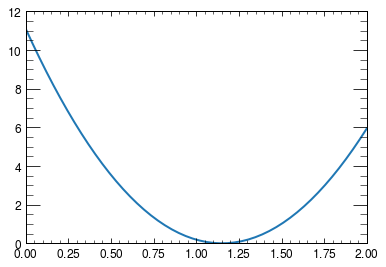

In [20]:
plt.plot(scan_points_nsbi, NLL_value_nsbi)
plt.axis(ymin=0)